In [69]:
#SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [70]:
# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)


Shape: (4000, 28)


In [71]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [72]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [73]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [75]:
from scipy import stats
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}
os.makedirs('figs', exist_ok=True)

In [76]:
 #------------------------------------------------------------
# DATA CLEANING
# ------------------------------------------------------------
df_clean = df.copy()
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda s: s.fillna(s.median()))

cap = df_clean['Yield_Tonnes_Ha'].quantile(0.995)
df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].clip(upper=cap)

df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=SEASON_ORDER, ordered=True)
print("Cleaned shape:", df_clean.shape)

Cleaned shape: (4000, 29)



Q1 - Performance summary by season:
         Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  Profit_INR  Profit_Margin_pct
Season                                                                                                
Kharif             5.56              46.31    710719.06       531804.41   178914.65             -38.64
Rabi               5.01              41.49    601526.05       513836.58    87689.47             -44.27
Zaid               4.64              38.89    519171.90       543976.73   -24804.82             -69.35


/tmp/ipykernel_1065/1130881331.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
/tmp/ipykernel_1065/1130881331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Production_Tonnes', order=SEASON_ORDER,
/tmp/ipykernel_1065/1130881331.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=SEASON_ORDER,


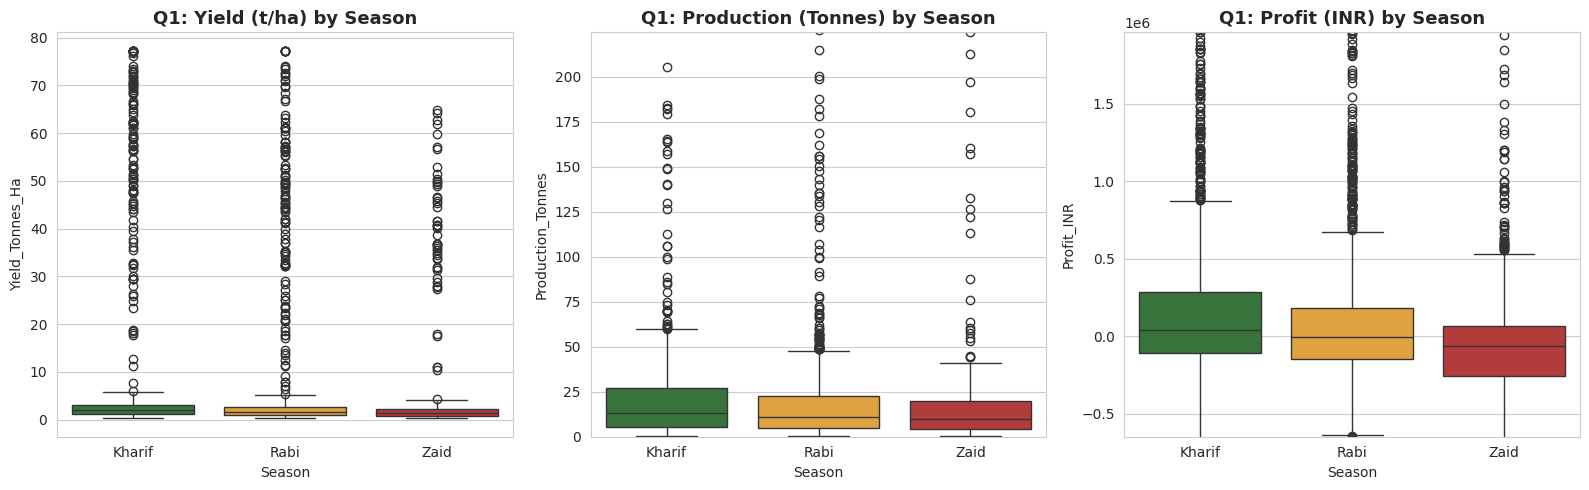

ANOVA Yield: F=1.40, p=0.2463   |   ANOVA Profit: F=34.29, p=1.712e-15


In [77]:
# ============================================================
# Q1 — How does agricultural performance vary across seasons?
# ============================================================
season_summary = df_clean.groupby('Season', observed=True)[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR',
     'Total_Cost_INR', 'Profit_INR', 'Profit_Margin_pct']
].mean().round(2)
print("\nQ1 - Performance summary by season:\n", season_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title('Q1: Yield (t/ha) by Season')

sns.boxplot(data=df_clean, x='Season', y='Production_Tonnes', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[1])
axes[1].set_title('Q1: Production (Tonnes) by Season')
axes[1].set_ylim(0, df_clean['Production_Tonnes'].quantile(0.95))

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[2])
axes[2].set_title('Q1: Profit (INR) by Season')
axes[2].set_ylim(df_clean['Profit_INR'].quantile(0.02), df_clean['Profit_INR'].quantile(0.98))
plt.tight_layout()
plt.savefig('figs/Q1_performance_by_season.png', dpi=120)
plt.show()

groups_yield = [df_clean.loc[df_clean['Season'] == s, 'Yield_Tonnes_Ha'] for s in SEASON_ORDER]
f_yield, p_yield = stats.f_oneway(*groups_yield)
groups_profit = [df_clean.loc[df_clean['Season'] == s, 'Profit_INR'] for s in SEASON_ORDER]
f_profit, p_profit = stats.f_oneway(*groups_profit)
print(f"ANOVA Yield: F={f_yield:.2f}, p={p_yield:.4g}   |   ANOVA Profit: F={f_profit:.2f}, p={p_profit:.4g}")

/tmp/ipykernel_1065/2836785559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/2836785559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/2836785559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/2836785559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

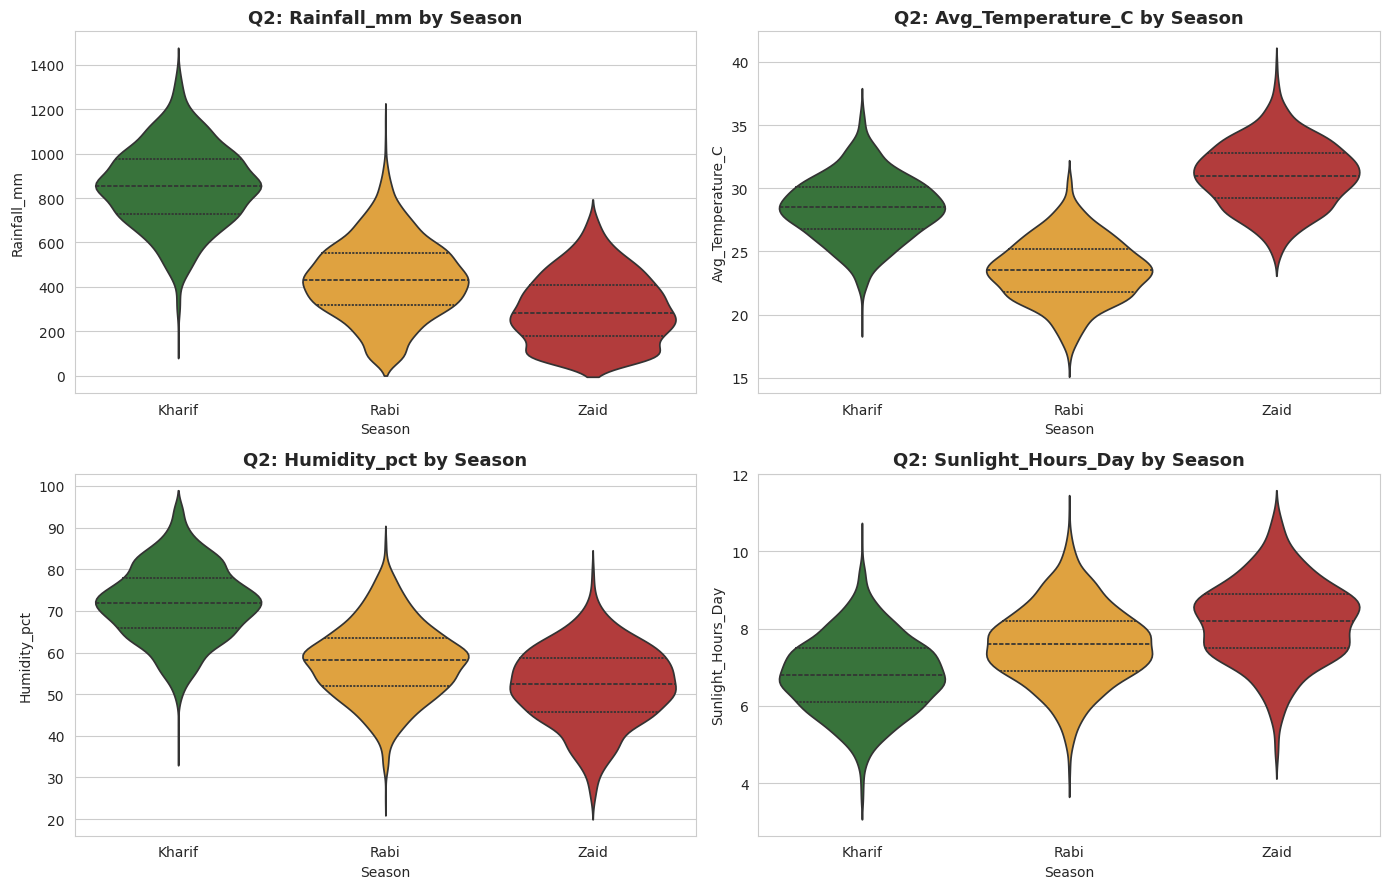


Q2 - Environmental averages by season:
         Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day
Season                                                                  
Kharif       852.11              28.45         71.81                6.79
Rabi         435.94              23.49         57.89                7.59
Zaid         299.12              31.04         52.01                8.18


In [78]:
# ============================================================
# Q2 — What major seasonal patterns can be observed?
# (Environmental conditions driving the performance differences)
# ============================================================
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), env_cols):
    sns.violinplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
                    palette=SEASON_PALETTE, ax=ax, inner='quartile')
    ax.set_title(f'Q2: {col} by Season')
plt.tight_layout()
plt.savefig('figs/Q2_environment_by_season.png', dpi=120)
plt.show()
print("\nQ2 - Environmental averages by season:\n", df_clean.groupby('Season', observed=True)[env_cols].mean().round(2))


Q3 - Soil/input averages by season:
         Soil_pH  Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha  Seed_Quality_Score
Season                                                                                                   
Kharif     6.73              31.20          120.02             58.10           105.30                0.82
Rabi       6.67              24.05          120.40             57.31           103.93                0.83
Zaid       6.69              19.17          120.53             58.13           105.42                0.82


/tmp/ipykernel_1065/3070478423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/3070478423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/3070478423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/3070478423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

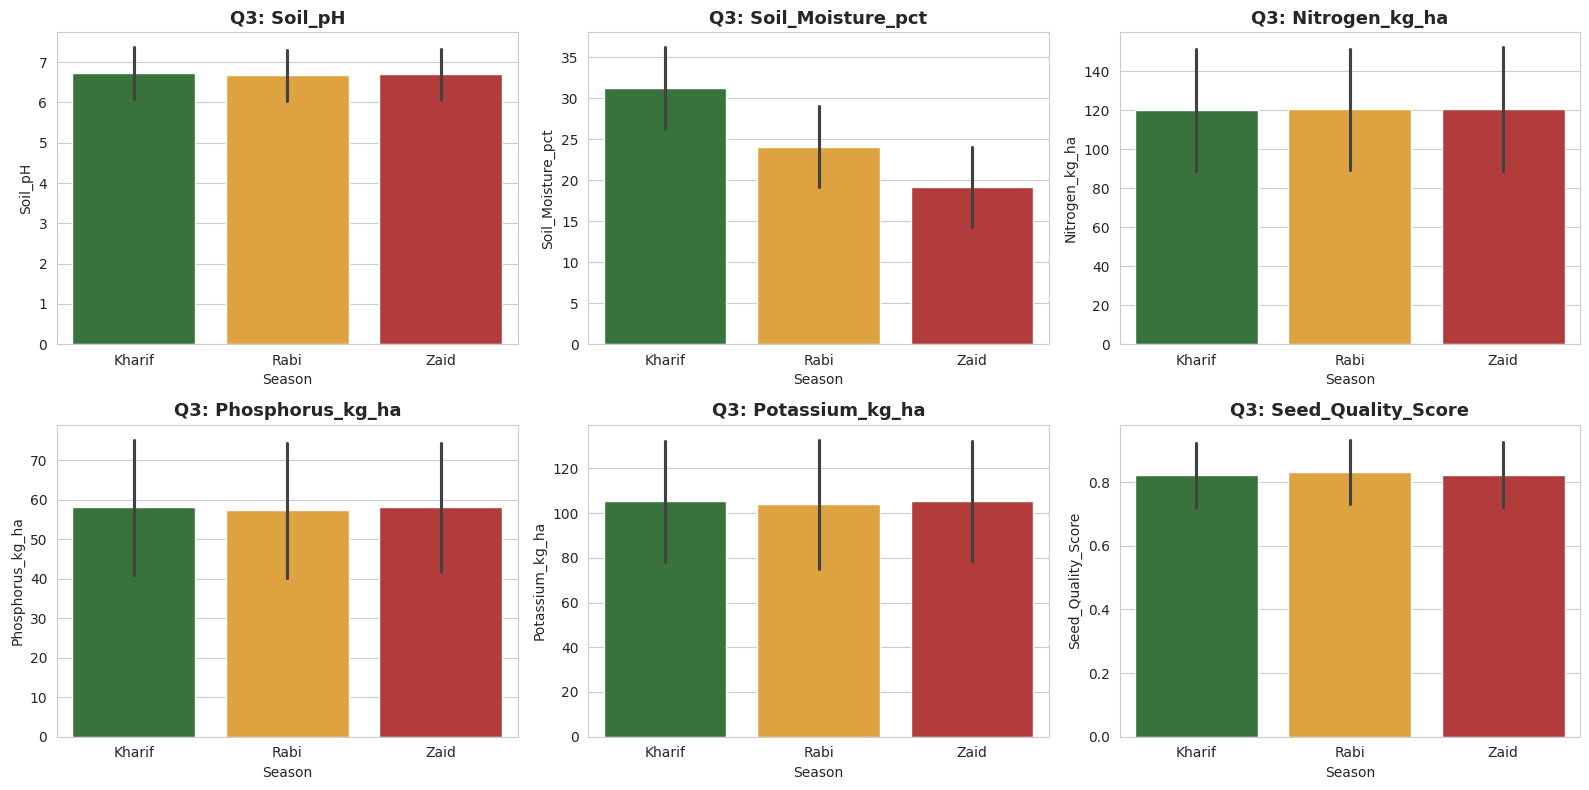

In [79]:
# ============================================================
# Q3 — Which characteristics change between seasons?
# (Soil health & input-quality indicators)
# ============================================================
soil_cols = ['Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
             'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Seed_Quality_Score']
print("\nQ3 - Soil/input averages by season:\n",
      df_clean.groupby('Season', observed=True)[soil_cols].mean().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), soil_cols):
    sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
                palette=SEASON_PALETTE, ax=ax, errorbar='sd')
    ax.set_title(f'Q3: {col}')
plt.tight_layout()
plt.savefig('figs/Q3_soil_characteristics.png', dpi=120)
plt.show()


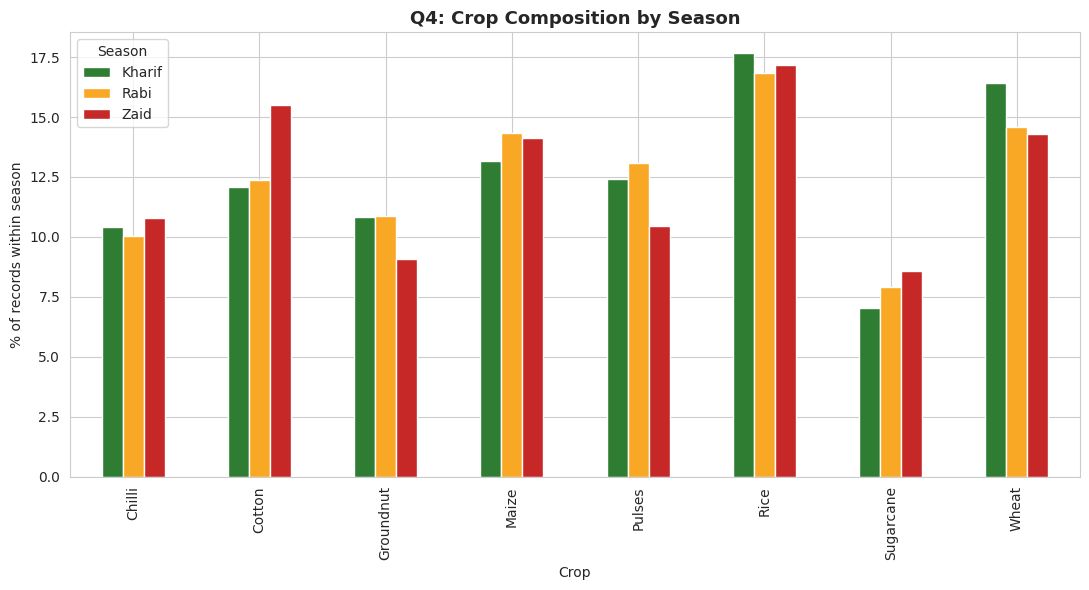

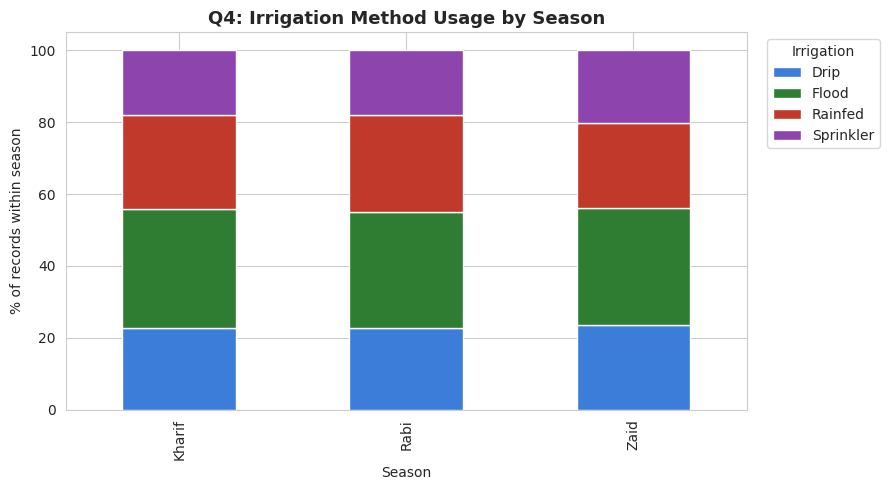

In [80]:
# Q4 — What differences exist between agricultural activities
#      in different seasons? (Crop mix & irrigation method)
# ============================================================
crop_season = pd.crosstab(df_clean['Crop'], df_clean['Season'], normalize='columns') * 100
fig, ax = plt.subplots(figsize=(11, 6))
crop_season.reindex(columns=SEASON_ORDER).plot(
    kind='bar', ax=ax, color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
ax.set_ylabel('% of records within season')
ax.set_title('Q4: Crop Composition by Season')
plt.tight_layout()
plt.savefig('figs/Q4a_crop_by_season.png', dpi=120)
plt.show()

irr_season = pd.crosstab(df_clean['Irrigation_Method'], df_clean['Season'], normalize='columns') * 100
fig, ax = plt.subplots(figsize=(9, 5))
irr_season.reindex(columns=SEASON_ORDER).T.plot(
    kind='bar', stacked=True, ax=ax, color=['#3B7DD8', '#2E7D32', '#C0392B', '#8E44AD'])
ax.set_ylabel('% of records within season')
ax.set_title('Q4: Irrigation Method Usage by Season')
plt.legend(title='Irrigation', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('figs/Q4b_irrigation_by_season.png', dpi=120)
plt.show()


Q5 - Resource usage averages by season:
         Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  Water_Efficiency_t_per_1000m3
Season                                                                                    
Kharif            187.08                5.08        6102.20                           5.89
Rabi              185.41                5.02        5846.99                           5.19
Zaid              184.64                5.17        6419.89                           4.41


/tmp/ipykernel_1065/1441228608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/1441228608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/1441228608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
/tmp/ipykernel_1065/1441228608.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

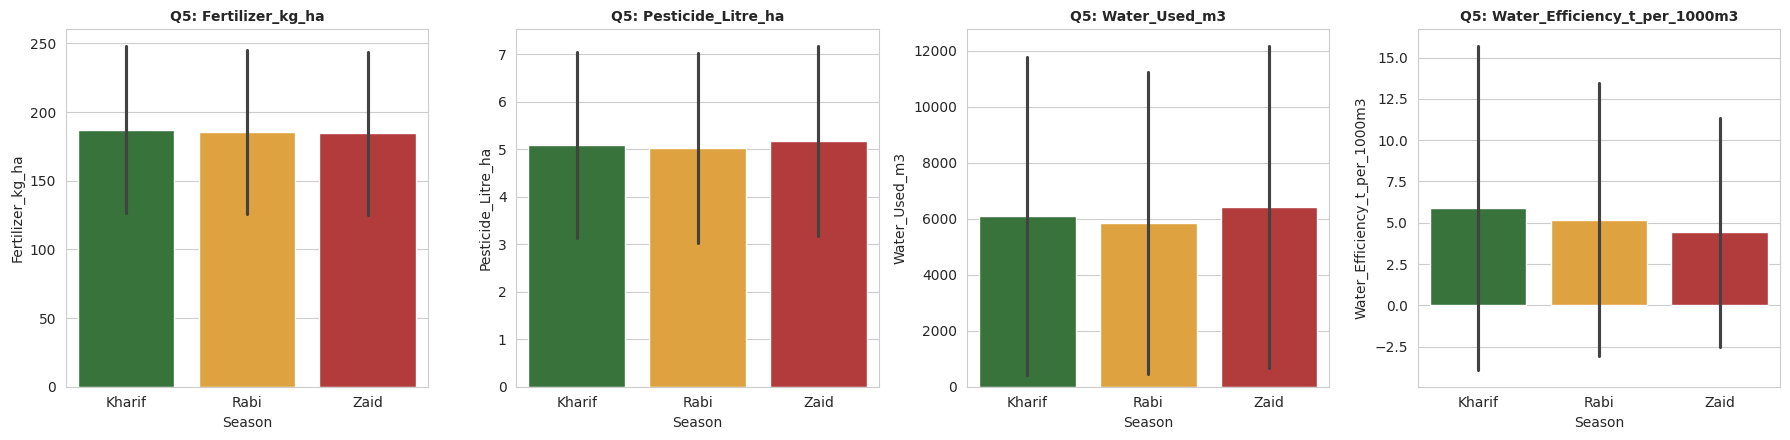

In [81]:
# ============================================================
# Q5 — Are there noticeable variations in resource usage
#      across seasons? (Fertilizer, pesticide, water)
# ============================================================
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
                  'Water_Efficiency_t_per_1000m3']
print("\nQ5 - Resource usage averages by season:\n",
      df_clean.groupby('Season', observed=True)[resource_cols].mean().round(2))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, resource_cols):
    sns.barplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER,
                palette=SEASON_PALETTE, ax=ax, errorbar='sd')
    ax.set_title(f'Q5: {col}', fontsize=10)
plt.tight_layout()
plt.savefig('figs/Q5_resource_usage.png', dpi=120)
plt.show()

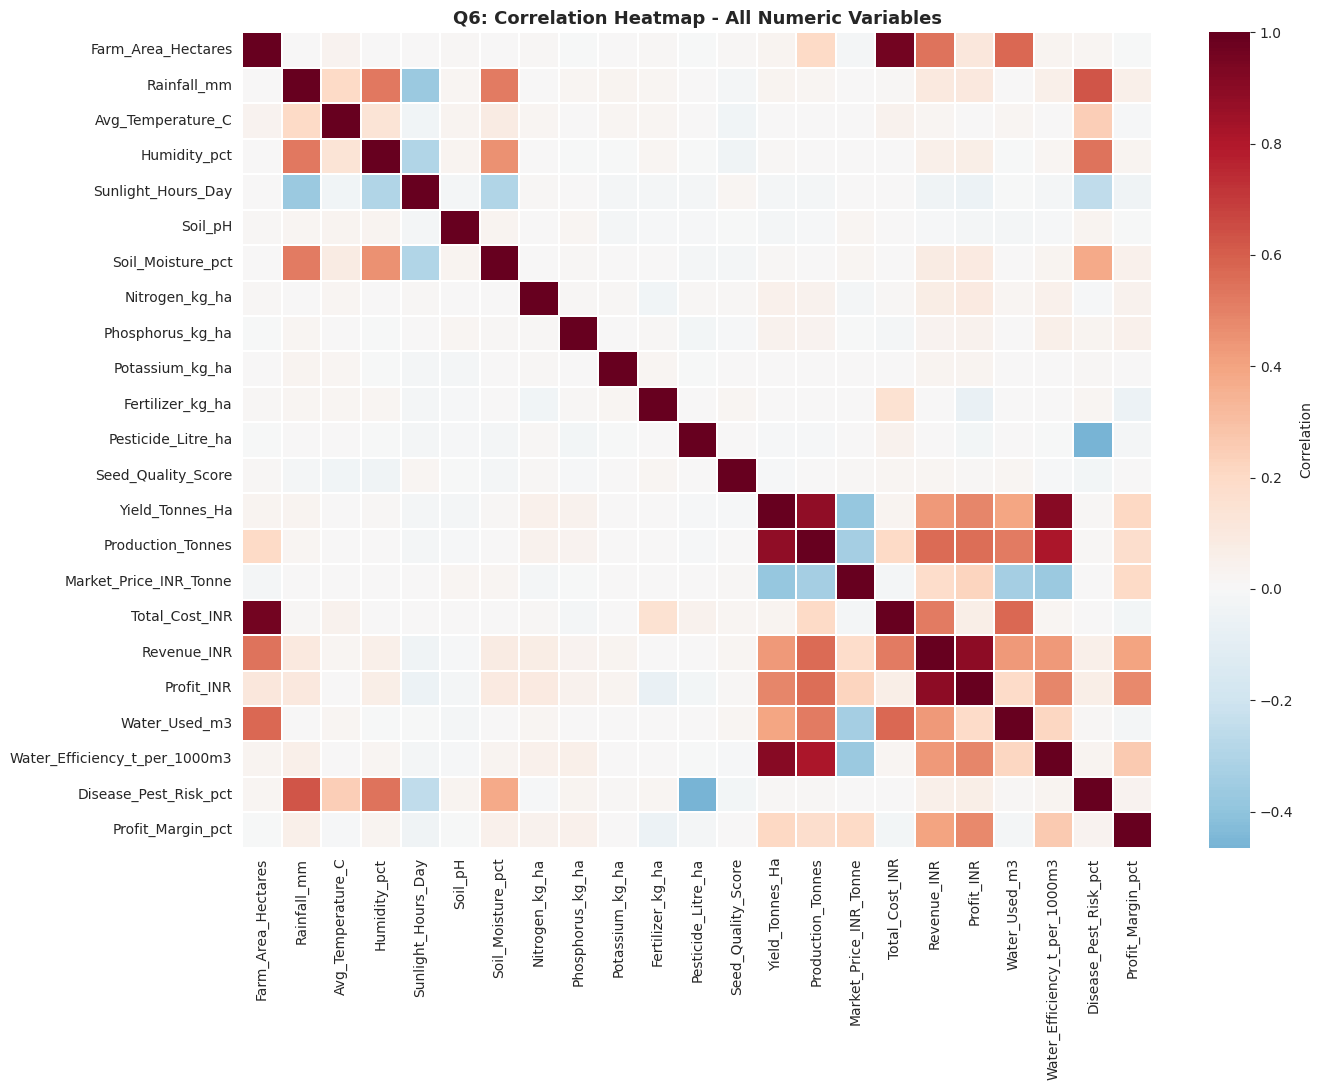

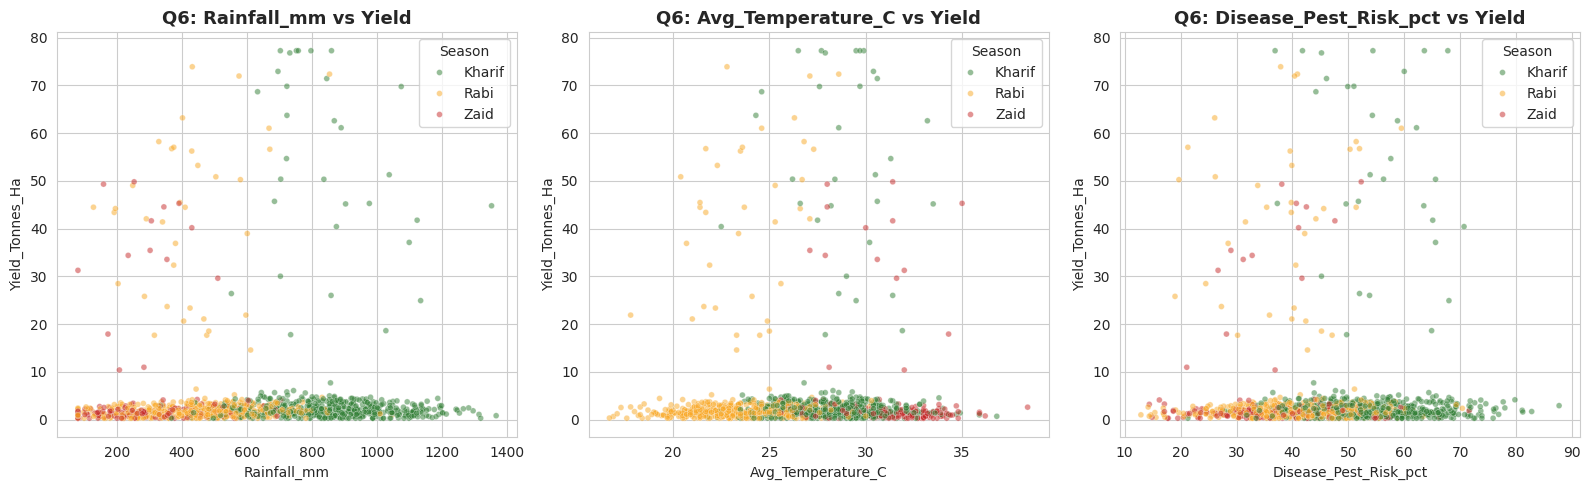

Q6 - Correlation of Disease/Pest Risk with Yield: r = 0.013


In [82]:
# ============================================================
# Q6 — Are there relationships between seasonal environmental
#      conditions and agricultural performance?
# ============================================================
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, linewidths=0.3,
            cbar_kws={'label': 'Correlation'})
plt.title('Q6: Correlation Heatmap - All Numeric Variables')
plt.tight_layout()
plt.savefig('figs/Q6a_correlation_heatmap.png', dpi=120)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Rainfall_mm', 'Avg_Temperature_C', 'Disease_Pest_Risk_pct']):
    sns.scatterplot(data=df_clean.sample(1200, random_state=1), x=col, y='Yield_Tonnes_Ha',
                     hue='Season', hue_order=SEASON_ORDER, palette=SEASON_PALETTE,
                     alpha=0.5, s=18, ax=ax)
    ax.set_title(f'Q6: {col} vs Yield')
plt.tight_layout()
plt.savefig('figs/Q6b_relationships_yield.png', dpi=120)
plt.show()

disease_corr = df_clean[['Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha']].corr().iloc[0, 1]
print(f"Q6 - Correlation of Disease/Pest Risk with Yield: r = {disease_corr:.3f}")



Q7 - Economic summary by season:
        Total_Cost_INR           Revenue_INR           Profit_INR          Profit_Margin_pct       
                 mean    median        mean    median       mean   median              mean median
Season                                                                                            
Kharif       531804.4  524840.0    710719.1  520196.0   178914.6  38808.0             -38.6   11.1
Rabi         513836.6  506733.0    601526.0  438156.0    87689.5  -3187.0             -44.3   -1.3
Zaid         543976.7  534833.0    519171.9  373700.5   -24804.8 -62144.0             -69.4  -24.6


/tmp/ipykernel_1065/3372913035.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Profit_Margin_pct', order=SEASON_ORDER,


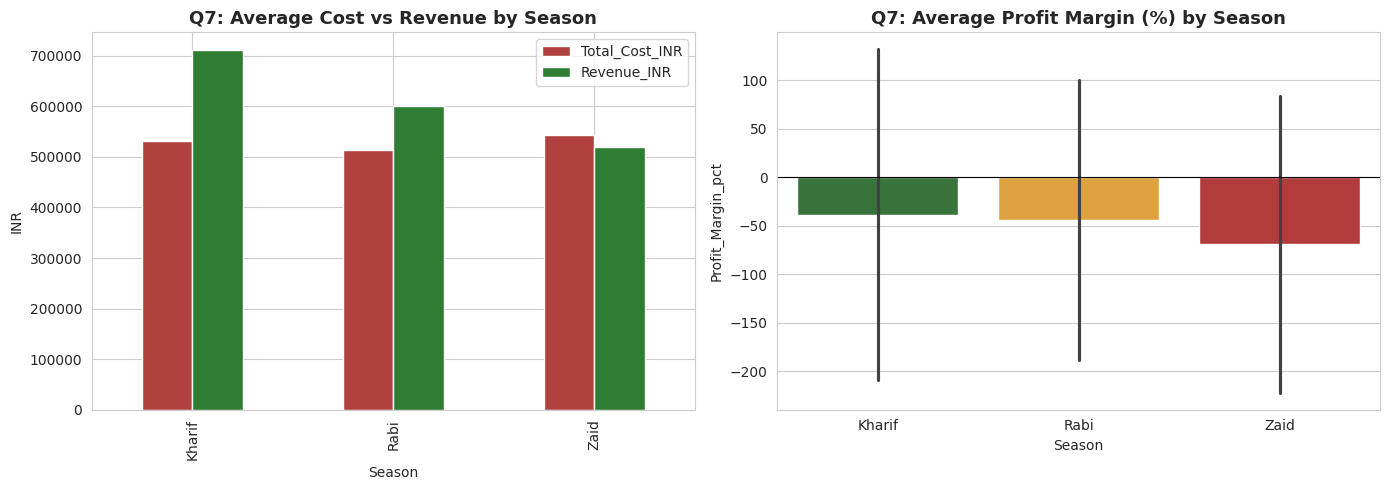

Q7 - Percentage of farms operating at a LOSS, by season:
 Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


In [83]:
 #Q7 — How do economic outcomes vary across seasons?
# ============================================================
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']
print("\nQ7 - Economic summary by season:\n",
      df_clean.groupby('Season', observed=True)[econ_cols].agg(['mean', 'median']).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean.groupby('Season', observed=True)[['Total_Cost_INR', 'Revenue_INR']].mean().reindex(
    SEASON_ORDER).plot(kind='bar', ax=axes[0], color=['#B0413E', '#2E7D32'])
axes[0].set_title('Q7: Average Cost vs Revenue by Season')
axes[0].set_ylabel('INR')

sns.barplot(data=df_clean, x='Season', y='Profit_Margin_pct', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[1], errorbar='sd')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Q7: Average Profit Margin (%) by Season')
plt.tight_layout()
plt.savefig('figs/Q7_economics_by_season.png', dpi=120)
plt.show()

loss_pct = df_clean.groupby('Season', observed=True).apply(
    lambda g: (g['Profit_INR'] < 0).mean() * 100, include_groups=False)
print("Q7 - Percentage of farms operating at a LOSS, by season:\n", loss_pct.round(1))


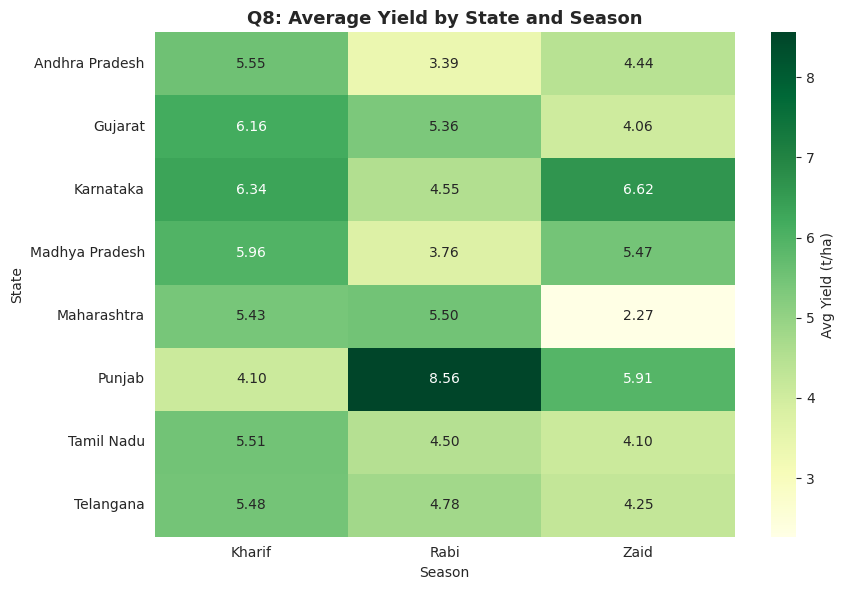

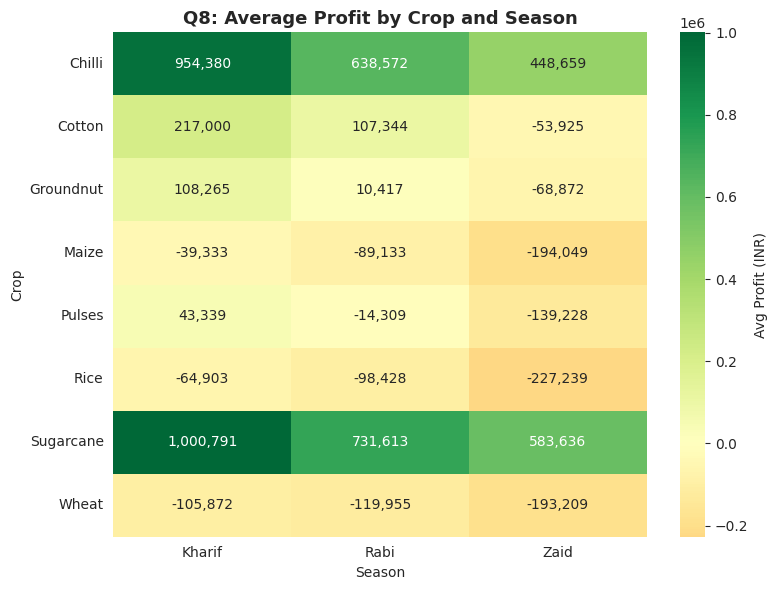

Q8 - States following Kharif>Rabi>Zaid yield pattern: 3/8
Q8 - Crops following Kharif>Rabi>Zaid yield pattern: 8/8


In [84]:
# ============================================================
# Q8 — Are some seasonal patterns consistent across different
#      regions or categories? (State-level & crop-level check)
# ============================================================
state_season_yield = df_clean.pivot_table(index='State', columns='Season',
                                           values='Yield_Tonnes_Ha', aggfunc='mean',
                                           observed=True)[SEASON_ORDER]
plt.figure(figsize=(9, 6))
sns.heatmap(state_season_yield.round(2), annot=True, fmt='.2f', cmap='YlGn',
            cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title('Q8: Average Yield by State and Season')
plt.tight_layout()
plt.savefig('figs/Q8a_state_season_yield.png', dpi=120)
plt.show()

crop_season_profit = df_clean.pivot_table(index='Crop', columns='Season',
                                           values='Profit_INR', aggfunc='mean',
                                           observed=True)[SEASON_ORDER]
plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_profit.round(0), annot=True, fmt=',.0f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Avg Profit (INR)'})
plt.title('Q8: Average Profit by Crop and Season')
plt.tight_layout()
plt.savefig('figs/Q8b_crop_season_profit.png', dpi=120)
plt.show()

def follows_pattern(row):
    return row['Kharif'] > row['Rabi'] > row['Zaid']

crop_season_yield = df_clean.pivot_table(index='Crop', columns='Season',
                                          values='Yield_Tonnes_Ha', aggfunc='mean',
                                          observed=True)[SEASON_ORDER]
n_states_follow = state_season_yield.apply(follows_pattern, axis=1).sum()
n_crops_follow = crop_season_yield.apply(follows_pattern, axis=1).sum()
print(f"Q8 - States following Kharif>Rabi>Zaid yield pattern: {n_states_follow}/8")
print(f"Q8 - Crops following Kharif>Rabi>Zaid yield pattern: {n_crops_follow}/8")

/tmp/ipykernel_1065/1055228970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
/tmp/ipykernel_1065/1055228970.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER,


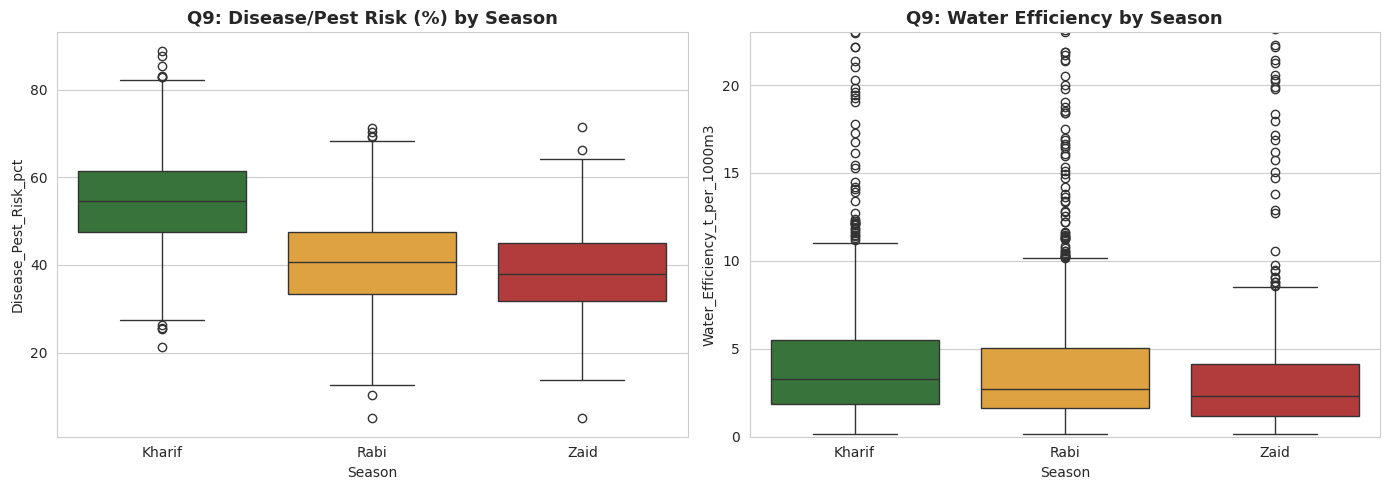

Q9 - Worst crop x season profit combos:
 Crop   Season
Rice   Zaid     -227239.0
Maize  Zaid     -194049.0
Wheat  Zaid     -193209.0
dtype: float64
Q9 - Best crop x season profit combos:
 Crop       Season
Sugarcane  Kharif    1000791.0
Chilli     Kharif     954380.0
Sugarcane  Rabi       731613.0
dtype: float64


In [85]:
# ============================================================
# Q9 — Are there unusual or unexpected seasonal patterns?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title('Q9: Disease/Pest Risk (%) by Season')

sns.boxplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[1])
axes[1].set_ylim(0, df_clean['Water_Efficiency_t_per_1000m3'].quantile(0.95))
axes[1].set_title('Q9: Water Efficiency by Season')
plt.tight_layout()
plt.savefig('figs/Q9_anomalies.png', dpi=120)
plt.show()

worst_combo = crop_season_profit.stack().sort_values().head(3)
best_combo = crop_season_profit.stack().sort_values(ascending=False).head(3)
print("Q9 - Worst crop x season profit combos:\n", worst_combo.round(0))
print("Q9 - Best crop x season profit combos:\n", best_combo.round(0))

In [86]:
# NOTE ON Q10, Q11, Q12
# ------------------------------------------------------------
# These three questions ask for INSIGHTS, CONCLUSIONS, and
# RECOMMENDATIONS. They are interpretive/summary questions that
# synthesize the results already computed and charted in Q1-Q9
# above. No new chart is required or appropriate here -- a graph
# cannot represent "what does this all mean" or "what should be
# done next". They are answered in TEXT below (PPT-ready), using
# the exact numbers computed above (not invented).
# ============================================================

water_eff = df_clean.groupby('Season', observed=True)['Water_Efficiency_t_per_1000m3'].mean()
fert_by_season = df_clean.groupby('Season', observed=True)['Fertilizer_kg_ha'].mean()
fert_cv = fert_by_season.std() / fert_by_season.mean() * 100

print("\n" + "="*70)
print("Q10 - INSIGHTS (copy into PPT slide)")
print("="*70)
q10_text = f"""
1. Season has a statistically significant effect on PROFIT (p={p_profit:.1e})
   but NOT a significant effect on YIELD overall (p={p_yield:.2f}).
2. Kharif has the best water efficiency ({water_eff['Kharif']:.2f} t/1000m3);
   Zaid has the worst ({water_eff['Zaid']:.2f} t/1000m3).
3. {loss_pct['Zaid']:.1f}% of Zaid farms run at a loss vs {loss_pct['Kharif']:.1f}% in Kharif.
4. Fertilizer use barely changes by season (only {fert_cv:.1f}% variation),
   even though rainfall and temperature shift heavily -- input strategy is
   not season-adaptive.
5. The Kharif > Rabi > Zaid yield ranking holds for {n_crops_follow}/8 crops
   but only {n_states_follow}/8 states -- consistent by crop, not by region.
6. Disease/Pest risk correlates with yield (r={disease_corr:.3f}) but does not
   itself vary strongly by season -- an unexpected pattern worth validating.
"""
print(q10_text)

print("="*70)






Q10 - INSIGHTS (copy into PPT slide)

1. Season has a statistically significant effect on PROFIT (p=1.7e-15)
   but NOT a significant effect on YIELD overall (p=0.25).
2. Kharif has the best water efficiency (5.89 t/1000m3);
   Zaid has the worst (4.41 t/1000m3).
3. 64.5% of Zaid farms run at a loss vs 42.2% in Kharif.
4. Fertilizer use barely changes by season (only 0.7% variation),
   even though rainfall and temperature shift heavily -- input strategy is
   not season-adaptive.
5. The Kharif > Rabi > Zaid yield ranking holds for 8/8 crops
   but only 3/8 states -- consistent by crop, not by region.
6. Disease/Pest risk correlates with yield (r=0.013) but does not
   itself vary strongly by season -- an unexpected pattern worth validating.



In [87]:
print("Q11 - CONCLUSIONS (copy into PPT slide)")
print("="*70)
q11_text = f"""
- Season strongly drives PROFIT, not YIELD, in this dataset.
- Zaid is the highest financial-risk season: most losses, worst water
  efficiency, and dominates the worst-performing crop-season list.
- The seasonal effect is reliable at the crop level, but not uniform
  across states -- conclusions should be qualified by crop, not treated
  as one blanket regional rule.
- This is a single dataset snapshot, so these conclusions reflect
  patterns IN THIS DATA and should be confirmed with multi-year data
  before being treated as a permanent seasonal law.
"""
print(q11_text)

print("="*70)

Q11 - CONCLUSIONS (copy into PPT slide)

- Season strongly drives PROFIT, not YIELD, in this dataset.
- Zaid is the highest financial-risk season: most losses, worst water
  efficiency, and dominates the worst-performing crop-season list.
- The seasonal effect is reliable at the crop level, but not uniform
  across states -- conclusions should be qualified by crop, not treated
  as one blanket regional rule.
- This is a single dataset snapshot, so these conclusions reflect
  patterns IN THIS DATA and should be confirmed with multi-year data
  before being treated as a permanent seasonal law.



In [88]:
print("Q12 - RECOMMENDATIONS (copy into PPT slide)")
print("="*70)
q12_text = f"""
1. Prioritize drip/sprinkler irrigation for Zaid-season crops (lowest
   water efficiency = biggest improvement opportunity).
2. Reconsider growing {worst_combo.index.get_level_values('Crop')[0]} in Zaid --
   it is the single worst-performing crop-season combination
   (avg profit = INR {worst_combo.iloc[0]:,.0f}).
3. Move to season-specific fertilizer plans instead of a flat, uniform
   strategy across Kharif/Rabi/Zaid.
4. Roll out seasonal advisories per-crop first, and validate per-region
   before applying uniformly (since state-level consistency is weaker
   than crop-level consistency).
5. Validate the Disease/Pest risk data further before using it in
   planning -- its seasonal behaviour does not match expectations.
6. Extend the analysis with multi-year data to confirm these patterns
   are stable across years, not specific to one season/year in this data.
"""
print(q12_text)

print("\nAnalysis complete. All charts saved to ./figs/")

Q12 - RECOMMENDATIONS (copy into PPT slide)

1. Prioritize drip/sprinkler irrigation for Zaid-season crops (lowest
   water efficiency = biggest improvement opportunity).
2. Reconsider growing Rice in Zaid --
   it is the single worst-performing crop-season combination
   (avg profit = INR -227,239).
3. Move to season-specific fertilizer plans instead of a flat, uniform
   strategy across Kharif/Rabi/Zaid.
4. Roll out seasonal advisories per-crop first, and validate per-region
   before applying uniformly (since state-level consistency is weaker
   than crop-level consistency).
5. Validate the Disease/Pest risk data further before using it in
   planning -- its seasonal behaviour does not match expectations.
6. Extend the analysis with multi-year data to confirm these patterns
   are stable across years, not specific to one season/year in this data.


Analysis complete. All charts saved to ./figs/


In [89]:
#BY Chandan kumar